# <b>AI Adoption, Hiring Trends & Tech Layoff Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# AI and Workforce Layoffs Analysis

## 1. Project Overview

This project analyzes workforce layoffs across multiple industries between 2024 and 2026. The dataset contains information related to layoffs, AI adoption, automation impact, employee sentiment, job security, revenue growth, hiring trends, and company performance.

The objective of this analysis is to identify patterns in workforce reductions, understand the impact of AI and automation on employment, and explore relationships between layoffs, employee sentiment, job security, and business growth using exploratory data analysis (EDA) techniques.

## 2. Dataset Overview

- Total Records: 12,000
- Total Features: 23
- Time Period: 2024–2026

The dataset contains information about:
- Layoffs
- AI Adoption
- AI Automation Impact
- AI Replacement Risk
- Open Roles
- Remote Work Percentage
- Revenue Growth
- Stock Growth
- Salary Budget Changes
- Employee Sentiment
- Job Security Score

In [2]:
df = pd.read_csv(r"tech_layoffs_hiring_trends_elite_v2.csv")
print(df.shape)
print(df.columns)
print(df.info)
df.head()

(12000, 23)
Index(['record_id', 'company_name', 'industry', 'country', 'company_size',
       'month', 'year', 'layoffs_count', 'layoff_percentage',
       'reason_for_layoffs', 'ai_automation_impact', 'ai_replacement_risk',
       'open_roles', 'hiring_trend', 'remote_jobs_percentage',
       'top_hiring_role', 'stock_growth_percent', 'revenue_growth_percent',
       'salary_budget_change', 'ai_adoption_level', 'employee_sentiment',
       'job_security_score', 'market_condition'],
      dtype='object')
<bound method DataFrame.info of       record_id company_name       industry    country company_size month  \
0            T0    Microsoft             AI  Singapore   Enterprise   Mar   
1            T1     Palantir             AI     Canada     Big Tech   Feb   
2            T2    Anthropic  Cybersecurity        USA     Mid-size   Apr   
3            T3      Spotify         Gaming        USA     Mid-size   Jun   
4            T4         Uber         Gaming         UK      Startup   Feb

,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,...,Moderate Hiring,46.7,ML Engineer,-25.7,30.3,4.9,4.4,8.7,8.6,Bull Market
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,...,Moderate Hiring,58.9,ML Engineer,-5.6,6.1,1.5,1.0,8.2,7.2,Bull Market
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,...,Hiring Freeze,85.4,Frontend Developer,7.0,-23.6,-14.9,5.6,4.5,5.9,Recession
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,...,Hiring Freeze,44.0,Frontend Developer,31.6,-22.3,-1.6,6.5,5.4,4.7,Recession
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,...,Moderate Hiring,53.2,Frontend Developer,85.3,26.6,9.8,9.3,6.7,5.8,Bull Market


## <b>2.Data Cleaning

In [3]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

record_id                 0
company_name              0
industry                  0
country                   0
company_size              0
month                     0
year                      0
layoffs_count             0
layoff_percentage         0
reason_for_layoffs        0
ai_automation_impact      0
ai_replacement_risk       0
open_roles                0
hiring_trend              0
remote_jobs_percentage    0
top_hiring_role           0
stock_growth_percent      0
revenue_growth_percent    0
salary_budget_change      0
ai_adoption_level         0
employee_sentiment        0
job_security_score        0
market_condition          0
dtype: int64
0
               year  layoffs_count  layoff_percentage  ai_automation_impact  \
count  12000.000000   12000.000000       12000.000000          12000.000000   
mean    2024.998750    5009.572083          12.780125              6.376983   
std        0.817703    5159.360491          10.212612              3.544012   
min     2024.000000      

## <B>3.Exploratory Data Analysis (EDA)

### 1.Which industries experienced the highest layoffs?

In [4]:
industry_layoffs=df.groupby('industry')['layoffs_count'].sum().sort_values(ascending=False)

industry_layoffs.head(7)

industry
Social Media     9012817
AI               8751526
E-Commerce       8618351
Cybersecurity    8569627
Gaming           8552964
FinTech          8406741
Cloud            8202839
Name: layoffs_count, dtype: int64

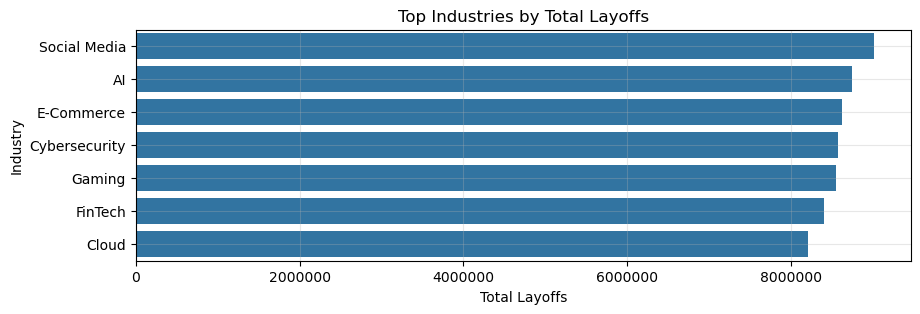

In [61]:
plt.figure(figsize=(10,3))

sns.barplot(
    x=industry_layoffs.values,
    y=industry_layoffs.index,
)

plt.grid(alpha=0.3)
plt.xlabel("Total Layoffs")
plt.ylabel("Industry")
plt.title("Top Industries by Total Layoffs")
plt.ticklabel_format(style='plain',axis='x')

plt.show()

**Insight:**
Social Media recorded the highest total layoffs among all industries, followed by AI and E-Commerce. This suggests that workforce reductions were concentrated in a few technology-driven sectors rather than being evenly distributed across industries.

### 2.Which countries experienced the highest layoffs?

In [6]:
country_layoffs=df.groupby('country')['layoffs_count'].sum().sort_values(ascending=False)

country_layoffs.head(10)

country
UK           10629082
Singapore    10078642
USA          10042659
Canada        9942815
India         9763402
Germany       9658265
Name: layoffs_count, dtype: int64

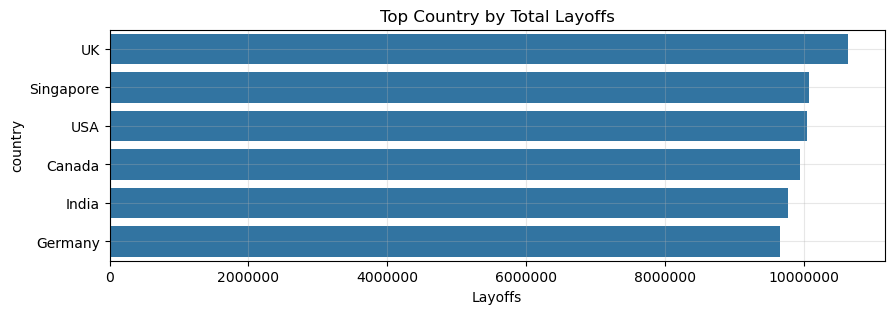

In [60]:
plt.figure(figsize=(10,3))
sns.barplot(
    x=country_layoffs.values,
    y=country_layoffs.index
)

plt.grid(alpha=0.3)
plt.xlabel('Layoffs')
plt.title('Top Country by Total Layoffs')
plt.ticklabel_format(style='plain',axis='x')

plt.show()

**Insight:**
Layoffs were concentrated in a few major economies, with the USA recording the highest workforce reductions. This suggests that large technology and enterprise markets experienced stronger restructuring activity.

### 3.Does AI adoption affect layoffs?

In [8]:
df['ai_adoption_level'].corr(df['layoffs_count'])

np.float64(0.0033599424428028086)

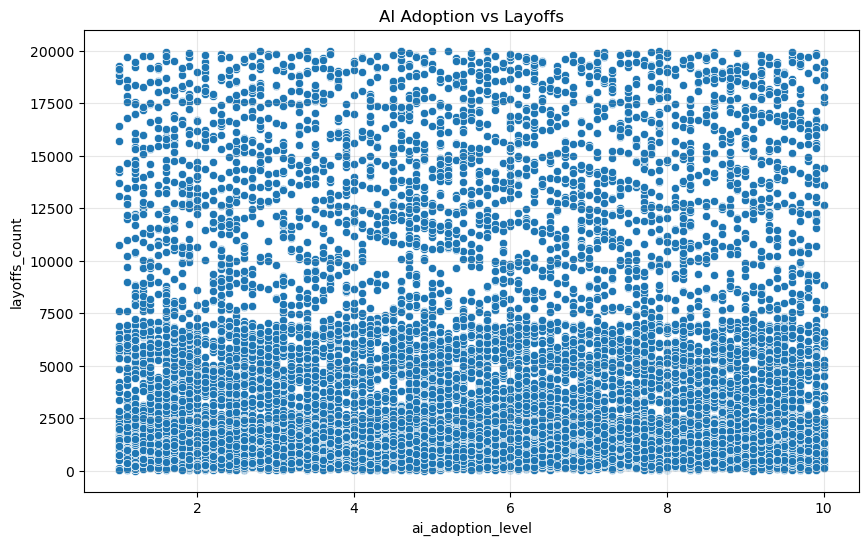

In [59]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='ai_adoption_level',
    y='layoffs_count',
    data=df
)

plt.grid(alpha=0.3)
plt.title("AI Adoption vs Layoffs")
plt.show()

**Insight:**
The correlation between AI adoption level and layoffs count is extremely weak (0.003). The scatter plot shows no clear pattern, suggesting that higher AI adoption does not directly correspond to higher layoffs in this dataset.

### 4.Which industries have the highest AI adoption levels?

In [10]:
ai_adp=df.groupby('industry')['ai_adoption_level'].mean().sort_values(ascending=False)
ai_adp.head(7)

industry
Cloud            5.612333
AI               5.591785
Gaming           5.571145
E-Commerce       5.521016
FinTech          5.516874
Social Media     5.481458
Cybersecurity    5.477946
Name: ai_adoption_level, dtype: float64

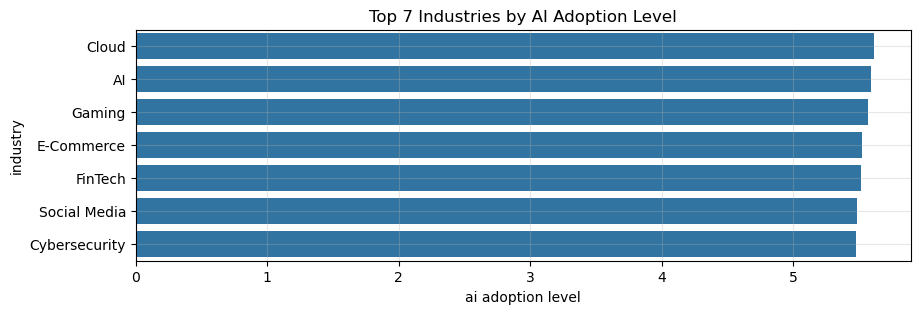

In [58]:
plt.figure(figsize=(10,3))
sns.barplot(
    x=ai_adp.values,
    y=ai_adp.index
)

plt.grid(alpha=0.3)
plt.xlabel('ai adoption level')
plt.title("Top 7 Industries by AI Adoption Level")
plt.show()

**Insight:**
AI adoption is highest in industries such as Cloud, Ai, and Gaming, suggesting that technology-driven sectors are leading AI integration compared to traditional industries.

### 5.Which industries have the lowest job security scores?

In [12]:
job_ss=df.groupby('industry')['job_security_score'].mean().sort_values(ascending=True)

job_ss.head(7)

industry
Social Media     5.725029
Cybersecurity    5.764819
E-Commerce       5.776443
Cloud            5.783072
AI               5.802187
FinTech          5.884192
Gaming           5.902395
Name: job_security_score, dtype: float64

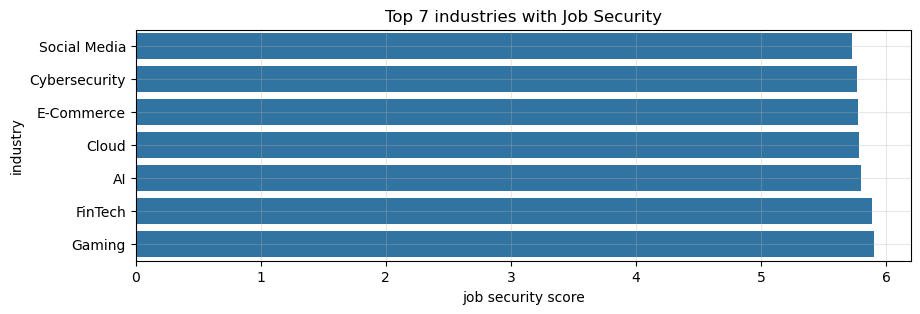

In [57]:
plt.figure(figsize=(10,3))

sns.barplot(
    x=job_ss.values,
    y=job_ss.index
)

plt.grid(alpha=0.3)
plt.title("Top 7 industries with Job Security")
plt.xlabel("job security score")
plt.show()

**Insight:**
The industries with the highest AI adoption levels are different from those reporting the lowest job security scores. This suggests that job security concerns may be influenced by multiple business factors beyond AI adoption alone.

### 6.Which industries have the highest employee sentiment?

In [14]:
emp_sentimate=df.groupby('industry')['employee_sentiment'].mean().sort_values(ascending=False)

emp_sentimate

industry
Gaming           6.542290
AI               6.518735
Cloud            6.517277
Cybersecurity    6.490548
FinTech          6.488277
E-Commerce       6.482275
Social Media     6.435419
Name: employee_sentiment, dtype: float64

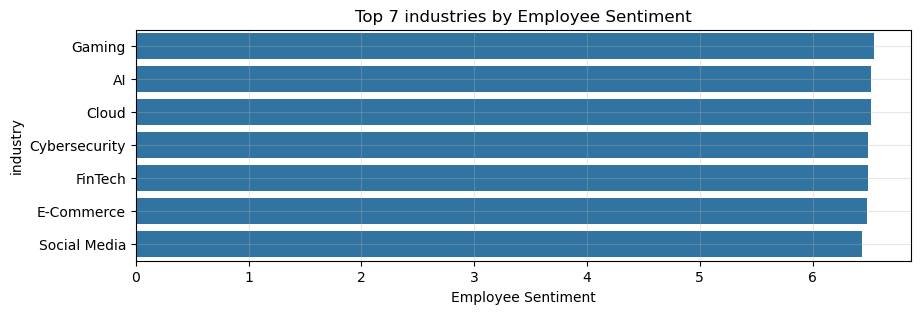

In [56]:
plt.figure(figsize=(10,3))

sns.barplot(
    x=emp_sentimate.values,
    y=emp_sentimate.index
)

plt.grid(alpha=0.3)
plt.xlabel('Employee Sentiment')
plt.title("Top 7 industries by Employee Sentiment")

plt.show()

**Insight:**
Gaming, AI, and Cloud industries report the highest employee sentiment scores, suggesting employees in these sectors are generally more optimistic and satisfied compared to other industries.

**Cross-Analysis Insight:**
The same industries that lead in AI adoption (Gaming, AI, and Cloud) also show the highest employee sentiment. This suggests that AI adoption in these sectors may be associated with positive employee perceptions rather than fear or dissatisfaction.

### 7.Which industries have both high AI adoption and high employee sentiment?

In [16]:
industry_metrics=df.groupby('industry')[['ai_adoption_level','employee_sentiment']].agg('mean')
industry_metrics.sort_values(by=['ai_adoption_level','employee_sentiment'],ascending=False)

,ai_adoption_level,employee_sentiment
industry,,
Cloud,5.612333,6.517277
AI,5.591785,6.518735
Gaming,5.571145,6.542290
E-Commerce,5.521016,6.482275
FinTech,5.516874,6.488277
Social Media,5.481458,6.435419
Cybersecurity,5.477946,6.490548


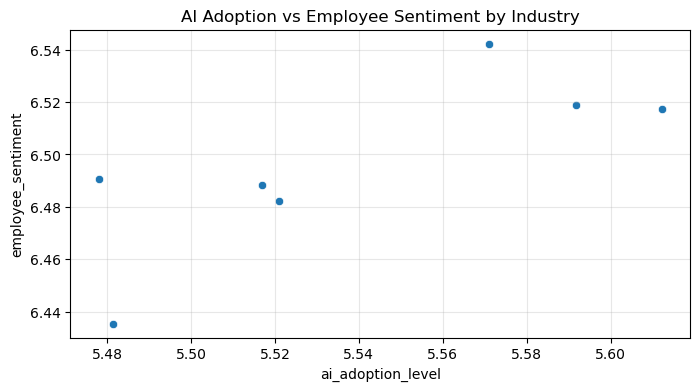

In [55]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=industry_metrics,
    x='ai_adoption_level',
    y='employee_sentiment'
)

plt.grid(alpha=0.3)
plt.title("AI Adoption vs Employee Sentiment by Industry")

plt.show()

**Insight:**
Gaming, AI, and Cloud industries consistently rank high in both AI adoption and employee sentiment. This suggests that employees in these sectors may view AI as an opportunity rather than a threat, indicating a positive relationship between technological advancement and workforce perception.

### 8.Which industries have high AI adoption but low job security?

In [18]:
industry_compare = df.groupby('industry')[['ai_adoption_level','job_security_score']].mean()

industry_compare

,ai_adoption_level,job_security_score
industry,,
AI,5.591785,5.802187
Cloud,5.612333,5.783072
Cybersecurity,5.477946,5.764819
E-Commerce,5.521016,5.776443
FinTech,5.516874,5.884192
Gaming,5.571145,5.902395
Social Media,5.481458,5.725029


In [19]:
industry_compare.sort_values(
    by=['ai_adoption_level','job_security_score'],
    ascending=[False, True]
).head(5)

,ai_adoption_level,job_security_score
industry,,
Cloud,5.612333,5.783072
AI,5.591785,5.802187
Gaming,5.571145,5.902395
E-Commerce,5.521016,5.776443
FinTech,5.516874,5.884192


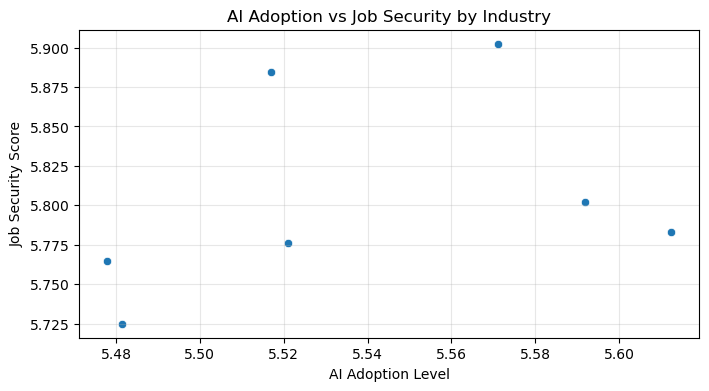

In [54]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=industry_compare,
    x='ai_adoption_level',
    y='job_security_score'
)

plt.grid(alpha=0.3)
plt.xlabel("AI Adoption Level")
plt.ylabel("Job Security Score")
plt.title("AI Adoption vs Job Security by Industry")

plt.show()

**Insight:**
Cloud, AI, and E-Commerce industries show relatively high AI adoption levels while maintaining below-average job security scores. This suggests employees in highly technology-driven sectors may feel more uncertain about long-term job stability despite strong AI integration.

### 9.Which industries have low employee sentiment and low job security?

In [21]:
lowEmpSec = df.groupby('industry')[['employee_sentiment','job_security_score']].mean()
lowEmpSec

,employee_sentiment,job_security_score
industry,,
AI,6.518735,5.802187
Cloud,6.517277,5.783072
Cybersecurity,6.490548,5.764819
E-Commerce,6.482275,5.776443
FinTech,6.488277,5.884192
Gaming,6.542290,5.902395
Social Media,6.435419,5.725029


In [22]:
lowEmpSec.sort_values(by=['employee_sentiment','job_security_score'],ascending=[True,True]).head(5)

,employee_sentiment,job_security_score
industry,,
Social Media,6.435419,5.725029
E-Commerce,6.482275,5.776443
FinTech,6.488277,5.884192
Cybersecurity,6.490548,5.764819
Cloud,6.517277,5.783072


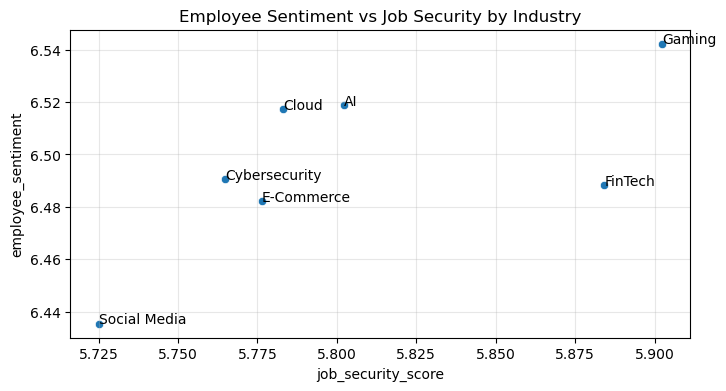

In [53]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=lowEmpSec,
    x='job_security_score',
    y='employee_sentiment'
)

for industry in lowEmpSec.index:
    plt.text(
        lowEmpSec.loc[industry,'job_security_score'],
        lowEmpSec.loc[industry,'employee_sentiment'],
        industry
    )

plt.grid(alpha=0.3)
plt.title("Employee Sentiment vs Job Security by Industry")
plt.show()

**Insight:**
Social Media and E-Commerce industries rank among the lowest in both employee sentiment and job security. This suggests employees in these sectors may feel less optimistic about their work environment and future career stability compared to employees in other industries.

**Cross Analysis:** Cloud is one of the most AI-adopted industries, yet it also shows relatively low job security and employee sentiment. This indicates that rapid technological transformation may create uncertainty among employees despite strong innovation and growth.

### 10.Which industries have the highest revenue growth but still experienced large layoffs?`

In [24]:
revLayOf=df.groupby('industry')[['revenue_growth_percent','layoffs_count']].mean()

revLayOf

,revenue_growth_percent,layoffs_count
industry,,
AI,17.257092,5172.296690
Cloud,17.561431,4771.866783
Cybersecurity,16.634772,4999.782380
E-Commerce,17.196651,4975.953233
FinTech,17.503020,4977.348135
Gaming,19.049299,4995.890187
Social Media,17.090356,5173.832951


In [25]:
revLayOf.sort_values(by=['revenue_growth_percent','layoffs_count'],ascending=[False,False]).head(7)

,revenue_growth_percent,layoffs_count
industry,,
Gaming,19.049299,4995.890187
Cloud,17.561431,4771.866783
FinTech,17.503020,4977.348135
AI,17.257092,5172.296690
E-Commerce,17.196651,4975.953233
Social Media,17.090356,5173.832951
Cybersecurity,16.634772,4999.782380


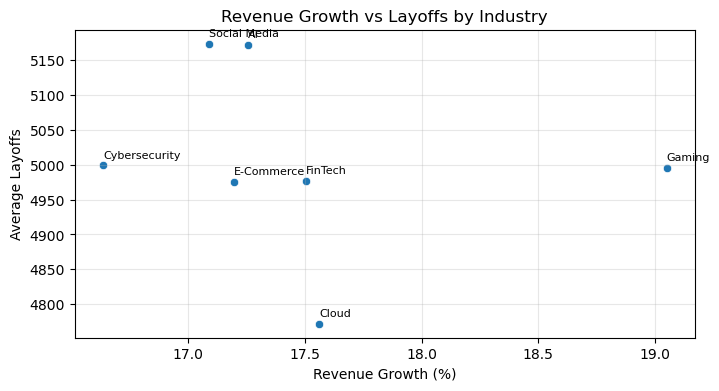

In [52]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=revLayOf,
    x='revenue_growth_percent',
    y='layoffs_count'
)

for i in revLayOf.index:
    plt.text(
        revLayOf.loc[i,'revenue_growth_percent'] + 0.0,
        revLayOf.loc[i,'layoffs_count'] + 10,
        i,
        fontsize=8
    )
plt.grid(alpha=0.3)
plt.title("Revenue Growth vs Layoffs by Industry")
plt.xlabel("Revenue Growth (%)")
plt.ylabel("Average Layoffs")

plt.show()

**Insight:**
Gaming, Cloud, AI, and Social Media industries show strong revenue growth while still reporting high layoff counts. This suggests that business growth does not necessarily translate into workforce expansion, possibly due to automation, restructuring, or productivity-driven strategies.

**Cross-Analysis Insight:**
Cloud and AI industries appear repeatedly across multiple analyses. They demonstrate strong revenue growth and high AI adoption, yet they also show signs of lower job security. This indicates that technological growth may be accompanied by workforce transformation rather than workforce expansion.

### 11.Do industries with higher remote work percentages have higher employee sentiment?

In [27]:
remote_sentiment=df.groupby('industry')[['remote_jobs_percentage','employee_sentiment']].mean()

remote_sentiment

,remote_jobs_percentage,employee_sentiment
industry,,
AI,50.550355,6.518735
Cloud,50.342583,6.517277
Cybersecurity,49.692357,6.490548
E-Commerce,50.150866,6.482275
FinTech,50.656720,6.488277
Gaming,50.062266,6.542290
Social Media,49.995350,6.435419


In [28]:
remote_sentiment.sort_values(by=['remote_jobs_percentage','employee_sentiment'],ascending=[False,False]).head()

,remote_jobs_percentage,employee_sentiment
industry,,
FinTech,50.656720,6.488277
AI,50.550355,6.518735
Cloud,50.342583,6.517277
E-Commerce,50.150866,6.482275
Gaming,50.062266,6.542290


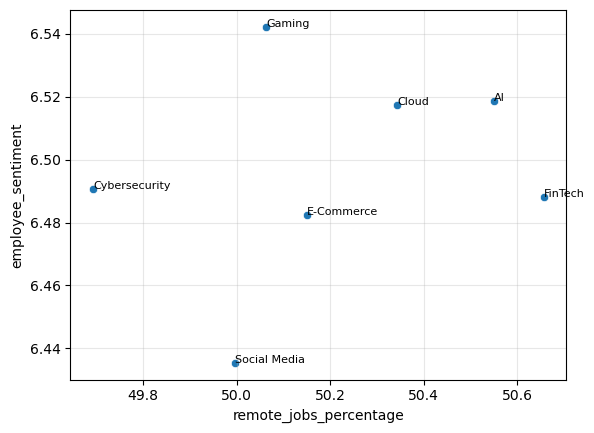

In [51]:
sns.scatterplot(
    x='remote_jobs_percentage',
    y='employee_sentiment',
    data=remote_sentiment
)

for i in remote_sentiment.index:
    plt.text(
        remote_sentiment.loc[i,'remote_jobs_percentage']+0.0,
        remote_sentiment.loc[i,'employee_sentiment']+0.,
        i,fontsize=8
    )

plt.grid(alpha=0.3)
plt.show()

**Insight:**
Remote work percentages are fairly consistent across industries, averaging around 50%. Employee sentiment also remains relatively stable across sectors. Based on this dataset, there is no strong evidence that industries with higher remote work percentages experience significantly higher employee sentiment.

**Cross-Analysis Insight:**
While AI, Cloud, and Gaming industries show high employee sentiment, the data suggests that remote work alone is unlikely to be the primary driver. Other factors such as industry growth, innovation, and AI adoption may have a stronger influence on employee perception.

### 12.Which industries have the highest AI replacement risk?

In [30]:
replacement_risk=df.groupby('industry')['ai_replacement_risk'].mean().sort_values(ascending=False)

replacement_risk

industry
Social Media     7.259300
E-Commerce       7.247748
AI               7.219740
Cloud            7.213264
Cybersecurity    7.190023
FinTech          7.167081
Gaming           7.162383
Name: ai_replacement_risk, dtype: float64

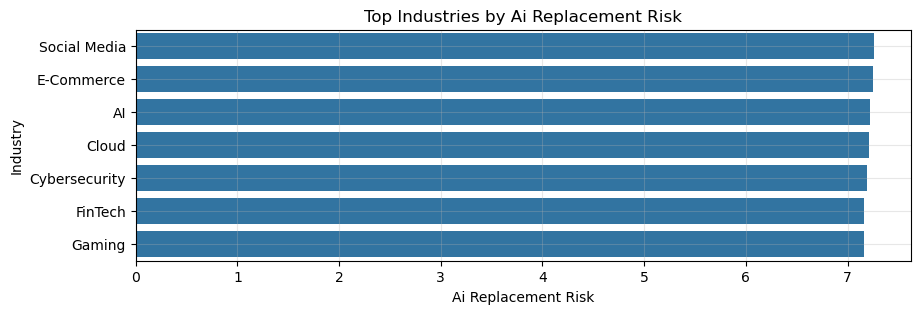

In [50]:
plt.figure(figsize=(10,3))

sns.barplot(
    x=replacement_risk.values,
    y=replacement_risk.index,
)

plt.xlabel("Ai Replacement Risk")
plt.ylabel("Industry")
plt.title("Top Industries by Ai Replacement Risk")
plt.grid(alpha=0.3)

plt.show()

In [32]:
df.columns

Index(['record_id', 'company_name', 'industry', 'country', 'company_size',
       'month', 'year', 'layoffs_count', 'layoff_percentage',
       'reason_for_layoffs', 'ai_automation_impact', 'ai_replacement_risk',
       'open_roles', 'hiring_trend', 'remote_jobs_percentage',
       'top_hiring_role', 'stock_growth_percent', 'revenue_growth_percent',
       'salary_budget_change', 'ai_adoption_level', 'employee_sentiment',
       'job_security_score', 'market_condition'],
      dtype='object')

**Insight:**
The AI, Cloud, and Social Media industries show the highest AI replacement risk scores. This suggests that employees in these sectors may be more exposed to automation and AI-driven workforce transformation compared to other industries.

**Cross Analysis:** Cloud and AI industries consistently appear among the leaders in AI adoption and AI replacement risk. While these sectors demonstrate strong technological growth, employees may face greater concerns regarding long-term job security due to increasing automation.

### 13.Which industries have high AI replacement risk but still maintain high employee sentiment?

In [33]:
repRiskHighSenti=df.groupby('industry')[['ai_replacement_risk','employee_sentiment']].mean()

repRiskHighSenti.sort_values(by=['ai_replacement_risk','employee_sentiment'],ascending=[False,False]).head(7)

,ai_replacement_risk,employee_sentiment
industry,,
Social Media,7.259300,6.435419
E-Commerce,7.247748,6.482275
AI,7.219740,6.518735
Cloud,7.213264,6.517277
Cybersecurity,7.190023,6.490548
FinTech,7.167081,6.488277
Gaming,7.162383,6.542290


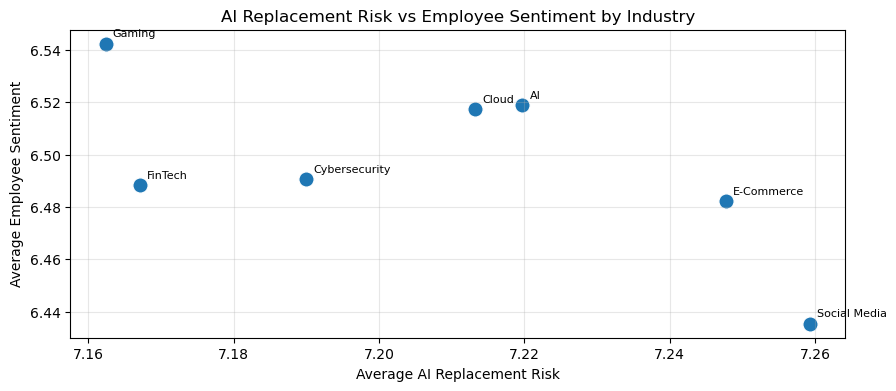

In [34]:
plt.figure(figsize=(10,4))

sns.scatterplot(
    data=repRiskHighSenti,
    x='ai_replacement_risk',
    y='employee_sentiment',
    s=120
)

for i in repRiskHighSenti.index:
    plt.annotate(
        i,
        (
            repRiskHighSenti.loc[i,'ai_replacement_risk'],
            repRiskHighSenti.loc[i,'employee_sentiment']
        ),
        xytext=(5,5),
        textcoords='offset points',
        fontsize=8
    )

plt.title("AI Replacement Risk vs Employee Sentiment by Industry")
plt.xlabel("Average AI Replacement Risk")
plt.ylabel("Average Employee Sentiment")
plt.grid(alpha=0.3)

plt.show()

**Insight:**
AI replacement risk remains relatively similar across all industries, ranging between 7.16 and 7.25. Employee sentiment also stays stable between 6.43 and 6.54. This suggests that despite concerns regarding AI-driven workforce disruption, employee sentiment does not appear to decline significantly in industries facing higher replacement risk.

**Cross Analysis:** AI, Cloud, and Gaming industries show high AI adoption, high employee sentiment, and relatively high AI replacement risk. This suggests employees in these sectors may perceive AI as a productivity-enhancing technology rather than a direct threat to their careers.

In contrast, Social Media and E-Commerce show both lower employee sentiment and higher AI replacement risk, indicating greater workforce uncertainty in these sectors.

### 14.How have layoffs changed from 2024 to 2026?

In [35]:
year_layoffs = df.groupby('year')['layoffs_count'].sum()

year_layoffs

year
2024    20307870
2025    19761032
2026    20045963
Name: layoffs_count, dtype: int64

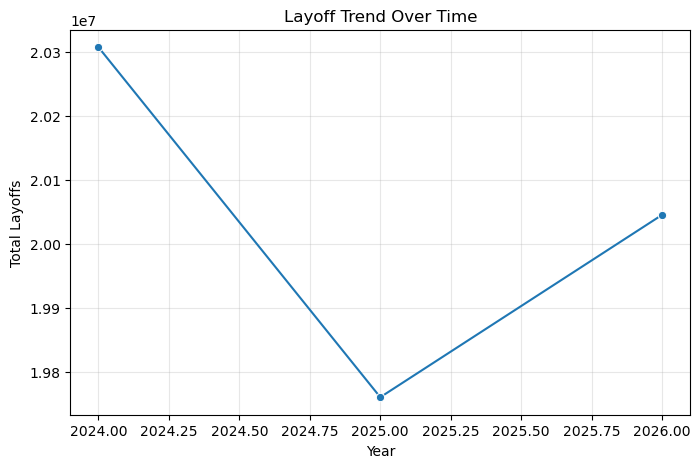

In [43]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=year_layoffs.index,
    y=year_layoffs.values,
    marker='o'
)

plt.title("Layoff Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Layoffs")
plt.grid(alpha=0.3)


plt.show()

**Insight:**
Layoffs remained relatively stable between 2024 and 2026, fluctuating around 20 million employees annually. While 2025 experienced a slight decline in layoffs, workforce reductions increased again in 2026, suggesting that layoffs continued to be a common business strategy throughout the period rather than a one-time event.

### 15.What is the distribution of layoffs_count?

In [37]:
df['layoffs_count'].describe()

count    12000.000000
mean      5009.572083
std       5159.360491
min          0.000000
25%       1369.500000
50%       2733.000000
75%       6490.000000
max      19999.000000
Name: layoffs_count, dtype: float64

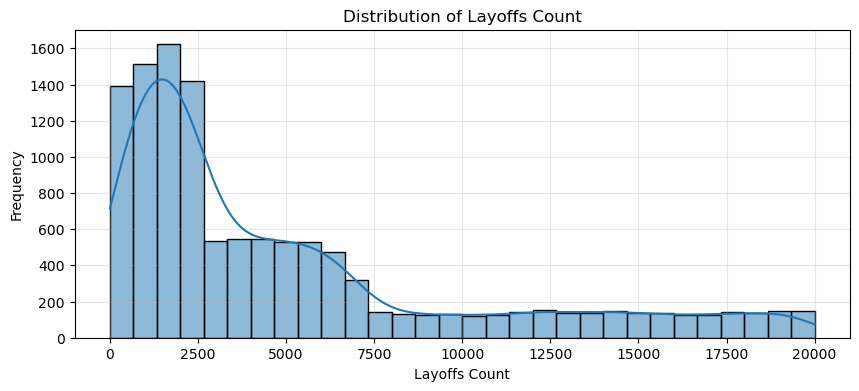

In [49]:
plt.figure(figsize=(10,4))

sns.histplot(
    df['layoffs_count'],
    bins=30,
    kde=True
)

plt.title("Distribution of Layoffs Count")
plt.xlabel("Layoffs Count")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

**Insight:**
Most layoff events involve fewer than 3,000 employees. However, a small number of companies experienced extremely large layoffs, reaching up to 20,000 employees. This indicates that large-scale workforce reductions are relatively rare but have a significant impact on overall layoff statistics.

### 17.Which industries show the widest variation in layoffs?

In [39]:
df.groupby('industry')['layoffs_count'].describe()

,count,mean,std,min,25%,50%,75%,max
industry,,,,,,,,
AI,1692.0,5172.296690,5153.639339,0.0,1505.75,3050.5,6723.00,19913.0
Cloud,1719.0,4771.866783,5092.316335,4.0,1280.50,2431.0,6147.00,19965.0
Cybersecurity,1714.0,4999.782380,5131.368406,11.0,1437.25,2706.0,6484.00,19979.0
E-Commerce,1732.0,4975.953233,5186.287677,0.0,1314.50,2657.0,6360.25,19988.0
FinTech,1689.0,4977.348135,5138.140832,5.0,1394.00,2665.0,6554.00,19968.0
Gaming,1712.0,4995.890187,5171.698507,6.0,1342.25,2783.0,6407.25,19999.0
Social Media,1742.0,5173.832951,5237.211615,2.0,1358.50,3018.5,6751.25,19983.0


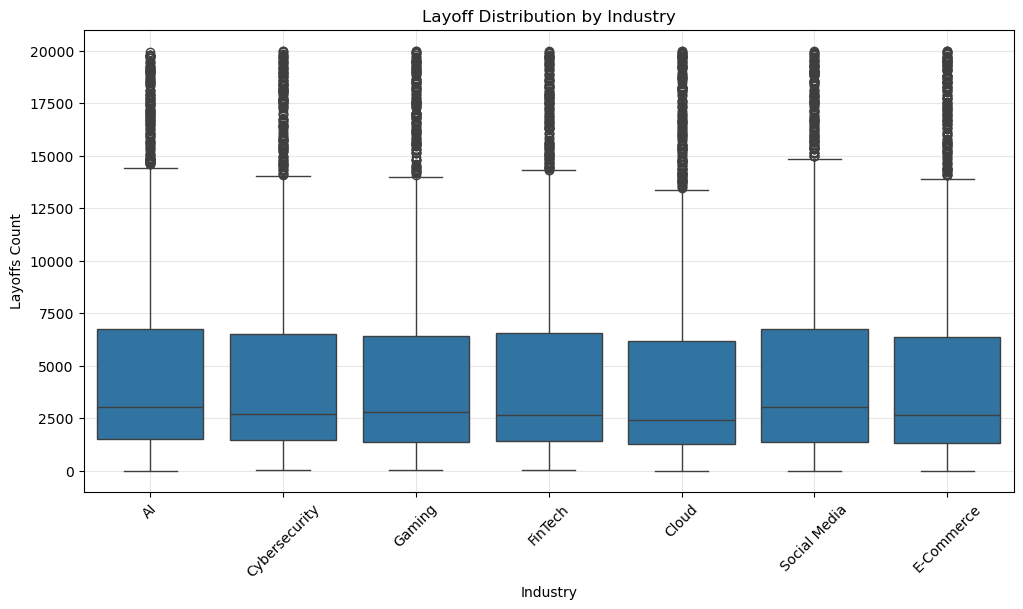

In [46]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='industry',
    y='layoffs_count'
)

plt.title("Layoff Distribution by Industry")
plt.xlabel("Industry")
plt.ylabel("Layoffs Count")
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.show()

**Insight:**
AI and Social Media industries show the highest median layoff levels, indicating that a typical company in these sectors tends to conduct larger workforce reductions. Social Media also exhibits the widest layoff distribution, suggesting greater variability across companies. Additionally, all industries contain numerous extreme outliers, showing that a small number of companies experienced exceptionally large layoffs.

### 18.Which variables are most strongly related to layoffs?

In [41]:
corr_matrix = df.select_dtypes(include='number').corr()

corr_matrix['layoffs_count'].sort_values(ascending=False)

layoffs_count             1.000000
layoff_percentage         0.598016
ai_replacement_risk       0.297273
ai_adoption_level         0.003360
stock_growth_percent      0.003104
remote_jobs_percentage    0.002944
ai_automation_impact     -0.002134
year                     -0.003689
revenue_growth_percent   -0.004162
salary_budget_change     -0.159390
open_roles               -0.281907
employee_sentiment       -0.304119
job_security_score       -0.469297
Name: layoffs_count, dtype: float64

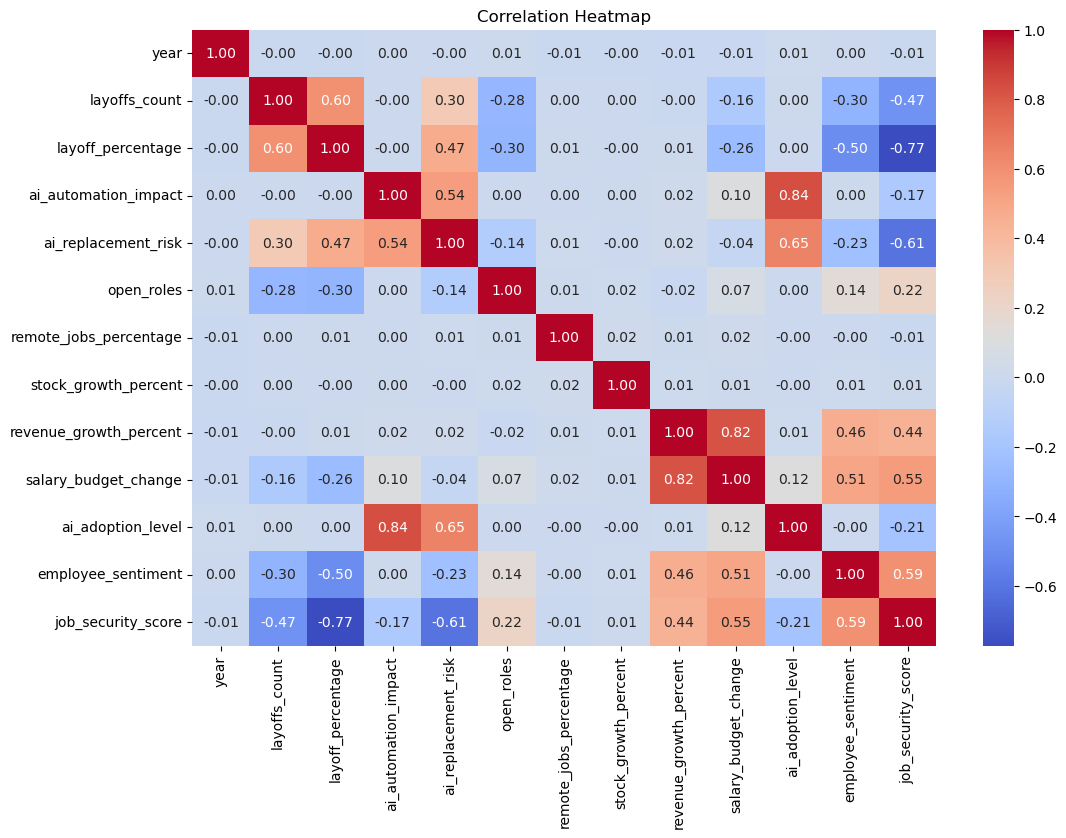

In [48]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

### Which variables are most strongly related to layoffs?

**Insight:**
Layoffs show the strongest positive relationship with layoff percentage (0.59), indicating that companies with larger workforce reductions generally report higher percentages of employees affected.

Job security score has the strongest negative relationship with layoffs (-0.47), suggesting that industries experiencing higher layoffs tend to have lower employee confidence in job stability.

Employee sentiment also decreases as layoffs increase (-0.30), indicating that workforce reductions negatively affect employee morale.

AI replacement risk has a moderate positive relationship with layoffs (0.30), implying that industries facing greater automation risk may experience more workforce reductions.

Interestingly, AI adoption level has almost no correlation with layoffs (0.003), suggesting that adopting AI alone does not necessarily result in job cuts.

## 5. Key Findings

1. Social Media and AI industries experienced the highest workforce reductions, indicating greater workforce instability compared to other sectors.

2. Layoffs remained relatively stable between 2024 and 2026, suggesting that workforce reductions were a persistent trend rather than a one-time event.

3. The distribution of layoffs was highly right-skewed, meaning most companies conducted small-to-medium layoffs while a few companies experienced extremely large workforce reductions.

4. AI, Cloud, and Gaming industries demonstrated high AI adoption levels while maintaining relatively strong employee sentiment, suggesting employees in these sectors may view AI as an opportunity rather than a threat.

5. Job security score showed the strongest negative relationship with layoffs (-0.47), indicating that industries with higher layoffs tend to have lower perceived job stability.

6. Employee sentiment was negatively correlated with layoffs (-0.30), suggesting that workforce reductions have a noticeable impact on employee morale.

7. AI replacement risk showed a moderate positive relationship with layoffs (0.30), implying that industries facing greater automation risk may experience higher workforce reductions.

8. AI adoption level showed almost no correlation with layoffs (0.003), indicating that adopting AI alone does not necessarily result in job cuts.

9. Social Media industry displayed the widest variation in layoffs, highlighting significant differences in workforce strategies among companies within the sector.

10. Open roles were negatively correlated with layoffs (-0.28), suggesting that industries conducting more layoffs generally offer fewer hiring opportunities.

## 6. Conclusion

This project explored workforce layoff trends across industries between 2024 and 2026, with a focus on AI adoption, automation risk, employee sentiment, job security, and business performance.

The analysis revealed that layoffs remained consistently high throughout the period, while employee sentiment and job security declined in industries experiencing larger workforce reductions. Although AI replacement risk showed a moderate relationship with layoffs, AI adoption itself demonstrated almost no direct correlation with workforce reductions. This suggests that layoffs are influenced by multiple business factors rather than AI adoption alone.

Overall, the findings indicate that workforce transformation is a complex process involving business strategy, automation risk, employee perception, hiring activity, and financial performance. These insights can help organizations better understand the relationship between technological change and workforce stability.